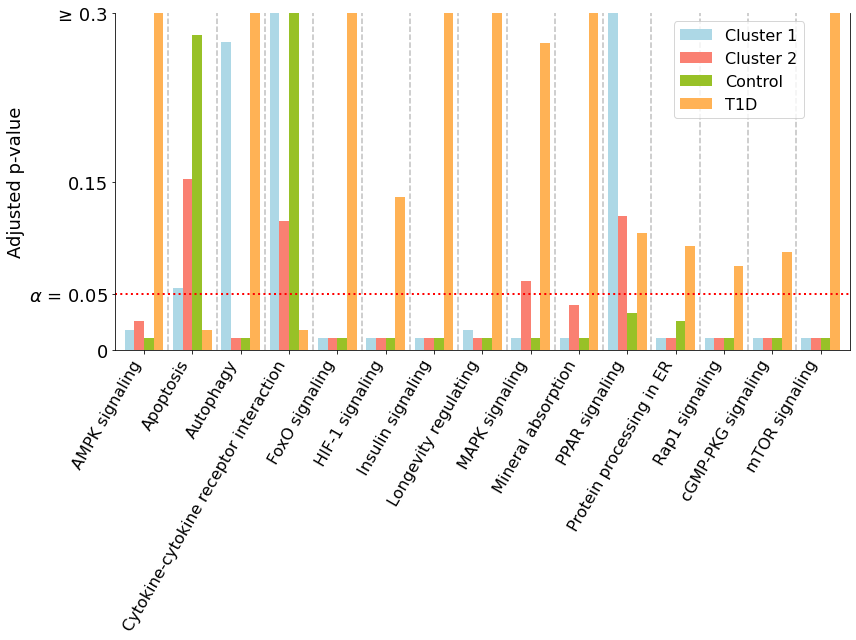

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FixedLocator, FixedFormatter
from statsmodels.stats.multitest import fdrcorrection

# Load the filtered dataframes from CSV
cluster1_df = pd.read_csv("/hpc/group/xielab/of21/pancreas_altered_diabetes_pathways_cluster1.csv")
cluster2_df = pd.read_csv("/hpc/group/xielab/of21/pancreas_altered_diabetes_pathways_cluster2.csv")
t1d_df = pd.read_csv("/hpc/group/xielab/of21/pancreas_altered_diabetes_pathways_t1d.csv")
control_df = pd.read_csv("/hpc/group/xielab/of21/pancreas_altered_diabetes_pathways_ctrl.csv")

# Extract common pathways from one dataframe (they are identical for all)
common_pathways = cluster1_df['pathway'].tolist()
common_pathways = sorted(list(common_pathways))

# Create dictionaries for each group
cluster1_dict = dict(zip(cluster1_df['pathway'], cluster1_df['p-value']))
cluster2_dict = dict(zip(cluster2_df['pathway'], cluster2_df['p-value']))
t1d_dict = dict(zip(t1d_df['pathway'], t1d_df['p-value']))
control_dict = dict(zip(control_df['pathway'], control_df['p-value']))

# Get p-values for each pathway, using 1.0 as default if not present
cluster1_pvalues = [cluster1_dict.get(pathway, 1.0) for pathway in common_pathways]
cluster2_pvalues = [cluster2_dict.get(pathway, 1.0) for pathway in common_pathways]
t1d_pvalues = [t1d_dict.get(pathway, 1.0) for pathway in common_pathways]
control_pvalues = [control_dict.get(pathway, 1.0) for pathway in common_pathways]

# Combine all p-values
all_pvalues = cluster1_pvalues + cluster2_pvalues + t1d_pvalues + control_pvalues

# Apply FDR-BH correction to all p-values together
_, all_adjusted = fdrcorrection(all_pvalues)

# Split the adjusted p-values back into their respective groups
n = len(common_pathways)
cluster1_adjusted = all_adjusted[:n]
cluster2_adjusted = all_adjusted[n:2*n]
t1d_adjusted = all_adjusted[2*n:3*n]
control_adjusted = all_adjusted[3*n:]

# Plotting
x = np.arange(len(common_pathways))  # the label locations
width = 0.2  # the width of the bars

# Set the figure size
fig, ax = plt.subplots(figsize=(12, 9))

# Function to replace values > 0.3 with np.nan for plotting
def replace_large_values(values):
    return [min(v, 0.3) for v in values]

rects1 = ax.bar(x - width*1.5, replace_large_values(cluster1_adjusted), width, label='Cluster 1', color='lightblue')
rects2 = ax.bar(x - width/2, replace_large_values(cluster2_adjusted), width, label='Cluster 2', color='salmon')
rects3 = ax.bar(x + width/2, replace_large_values(control_adjusted), width, label='Control', color='#98c127')
rects4 = ax.bar(x + width*1.5, replace_large_values(t1d_adjusted), width, label='T1D', color='#ffb255')

# Add vertical separating lines
for i in range(1, len(common_pathways)):
    ax.axvline(x=i - 0.5, color='gray', linestyle='--', alpha=0.5, zorder=0)

# Add text for labels, title, and custom x-axis tick labels
ax.set_ylabel('Adjusted p-value', fontsize=18)
ax.set_xticks(x)
ax.set_xticklabels(common_pathways, rotation=60, ha='right', fontsize=16)
ax.legend(bbox_to_anchor=(0.75, 1), loc='upper left', prop={'size': 16})

# Add a red dotted line at y=0.05
ax.axhline(y=0.05, color='red', linestyle='dotted', linewidth=2)

# Set y-axis limits and labels
ax.set_ylim(0, 0.3)
ax.yaxis.set_major_locator(FixedLocator([0, 0.05, 0.15, 0.3]))
ax.yaxis.set_major_formatter(FixedFormatter(['0', r'$\alpha$ = 0.05', '0.15', '≥ 0.3']))

# Set x-axis limits
ax.set_xlim([-0.6, len(common_pathways) - 0.8 + width*2])

# Increase font size of y-axis values
ax.tick_params(axis='y', labelsize=18)

# Remove the top border
ax.spines['top'].set_visible(False)

fig.tight_layout()

# Save the figure
#plt.savefig('/hpc/group/xielab/of21/pancreas_aab_pathways_final_fdr_corrected_combined_adjusted.jpeg', 
            #dpi=500, 
            #bbox_inches='tight',
            #pad_inches=0)

# Show the plot
plt.show()
